In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
file_path = "ApexPlanet_DataAnalytics_Dataset.xlsx"
df = pd.read_excel(file_path)

In [20]:
# data exploration 
print("="*60)
print("FIRST 5 ROWS")
print("="*60)

print(df.head())

print("\n")

print("="*60)
print("DATASET INFORMATION")
print("="*60)

print(df.info())

print("\n")

print("="*60)
print("DATASET SHAPE")
print("="*60)

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

FIRST 5 ROWS
    Order_ID  Order_Date Customer_ID Customer_Name   Age  Gender       City  \
0  ORD100002  2025-02-25    CUST5529  Customer_227  30.0  Female  Bengaluru   
1  ORD100003  2025-10-14    CUST3127  Customer_182  63.0    Male  Bengaluru   
2  ORD100004  2025-05-13    CUST8887  Customer_487  62.0  Female  Bengaluru   
3  ORD100005  2025-12-02    CUST2515  Customer_470  65.0  Female    Kolkata   
4  ORD100006  2025-11-20    CUST4796  Customer_380  44.0    Male  Bengaluru   

  Product     Category  Quantity  Unit_Price  Total_Sales  
0    Rice      Grocery         7     2829.77     19808.39  
1    Book    Education         5    27906.16    139530.80  
2    Book    Education         8    37491.06    299928.48  
3  Mobile  Electronics         9    28541.36    256872.24  
4    Rice      Grocery        10    14036.59    140365.90  


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-

In [22]:
# data cleaning 
print("\n")
print("="*60)
print("MISSING VALUES")
print("="*60)

print(df.isnull().sum())

print("\n")

print("="*60)
print("DUPLICATE ROWS")
print("="*60)

print("Duplicate Rows :", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()



MISSING VALUES
Order_ID          0
Order_Date        0
Customer_ID       0
Customer_Name     0
Age              20
Gender            0
City             13
Product           0
Category          0
Quantity          0
Unit_Price        0
Total_Sales       0
dtype: int64


DUPLICATE ROWS
Duplicate Rows : 0


In [23]:

# sales Calculation
print("\n")
print("="*60)
print("VERIFYING TOTAL SALES")
print("="*60)

sales_check = (
    df["Quantity"] * df["Unit_Price"]
    == df["Total_Sales"]
).all()

print("Sales Calculation Correct :", sales_check)



VERIFYING TOTAL SALES
Sales Calculation Correct : False


In [24]:
# descriptive statistics
print("\n")
print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)
print(df.describe())



DESCRIPTIVE STATISTICS
              Age     Quantity    Unit_Price    Total_Sales
count  980.000000  1000.000000   1000.000000    1000.000000
mean    41.360204     5.435000  25486.783410  139399.439650
std     13.822597     2.838632  14179.402361  114100.051546
min     18.000000     1.000000    145.780000     437.340000
25%     30.000000     3.000000  13895.722500   47066.632500
50%     41.000000     5.000000  25398.740000  108594.025000
75%     54.000000     8.000000  37512.382500  203722.882500
max     65.000000    10.000000  49997.530000  493677.500000


In [25]:
# numerical columns analysis
numerical_cols = [
    "Age",
    "Quantity",
    "Unit_Price",
    "Total_Sales"
]
print("\n")
print("="*60)
print("NUMERICAL SUMMARY")
print("="*60)
for col in numerical_cols:
    print(f"\n------ {col} ------")
    
    print("Mean :", df[col].mean())
    print("Median :", df[col].median())
    print("Minimum :", df[col].min())
    print("Maximum :", df[col].max())
    print("Std Dev :", df[col].std())



NUMERICAL SUMMARY

------ Age ------
Mean : 41.36020408163265
Median : 41.0
Minimum : 18.0
Maximum : 65.0
Std Dev : 13.82259729851074

------ Quantity ------
Mean : 5.435
Median : 5.0
Minimum : 1
Maximum : 10
Std Dev : 2.8386322116175657

------ Unit_Price ------
Mean : 25486.783409999996
Median : 25398.74
Minimum : 145.78
Maximum : 49997.53
Std Dev : 14179.402360973761

------ Total_Sales ------
Mean : 139399.43965000001
Median : 108594.025
Minimum : 437.34
Maximum : 493677.5
Std Dev : 114100.05154617458


In [26]:
# category distribution 
print("\n")
print("="*60)
print("CATEGORY DISTRIBUTION")
print("="*60)

print(df["Category"].value_counts())

# product distribution 
print("\n")
print("="*60)
print("PRODUCT DISTRIBUTION")
print("="*60)

print(df["Product"].value_counts())

# gender distribution
print("\n")
print("="*60)
print("GENDER DISTRIBUTION")
print("="*60)
print(df["Gender"].value_counts())

#  city distribution

print("\n")
print("="*60)
print("CITY DISTRIBUTION")
print("="*60)
print(df["City"].value_counts())



CATEGORY DISTRIBUTION
Category
Electronics    354
Education      178
Furniture      159
Fashion        156
Grocery        153
Name: count, dtype: int64


PRODUCT DISTRIBUTION
Product
Mobile    184
Book      178
Laptop    170
Chair     159
Shoes     156
Rice      153
Name: count, dtype: int64


GENDER DISTRIBUTION
Gender
Male      511
Female    489
Name: count, dtype: int64


CITY DISTRIBUTION
City
Patna        135
Kolkata      133
Mumbai       131
Hyderabad    125
Delhi        125
Bengaluru    122
Gaya         117
Pune          99
Name: count, dtype: int64


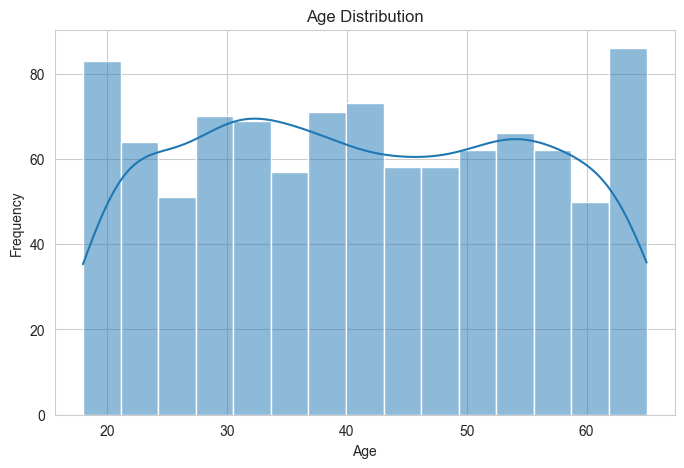

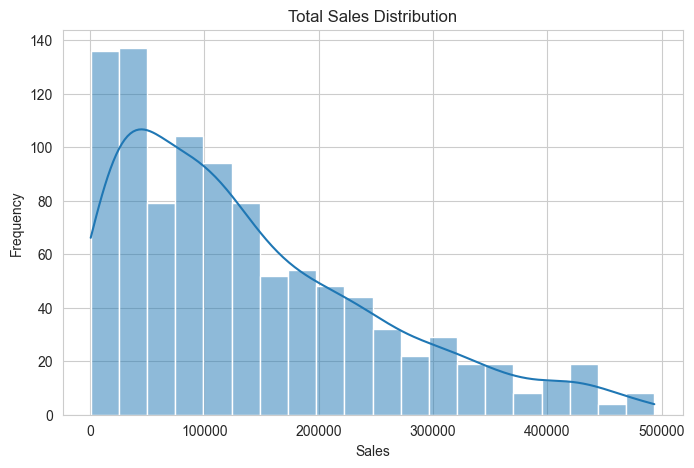

In [27]:
# age histogram
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Age",
    bins=15,
    kde=True
)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# sales histogram
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="Total_Sales",
    bins=20,
    kde=True
)
plt.title("Total Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

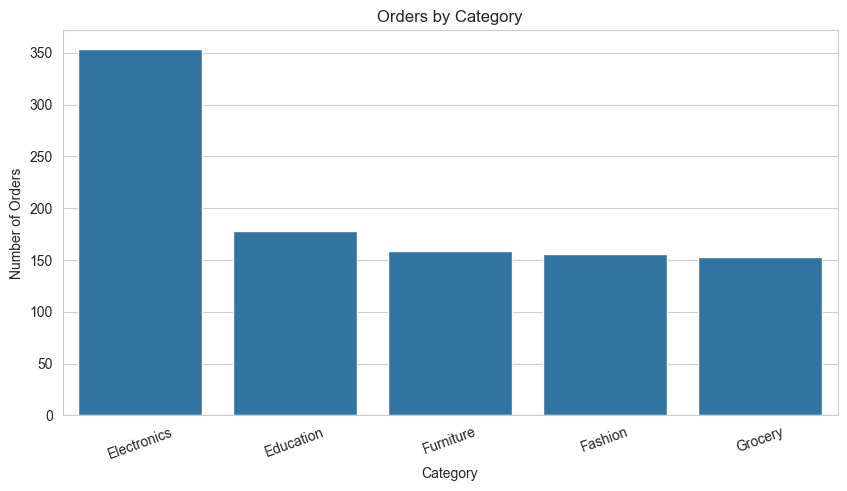

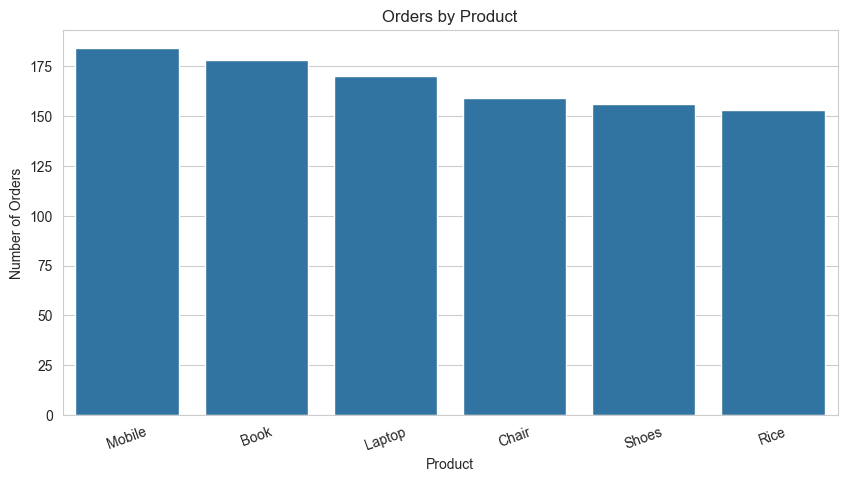

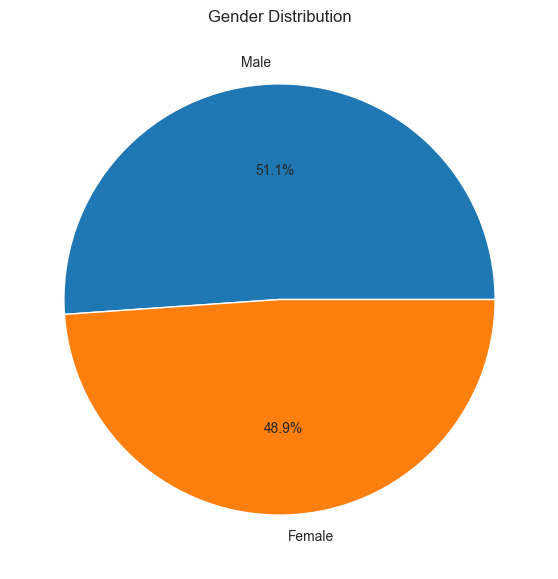

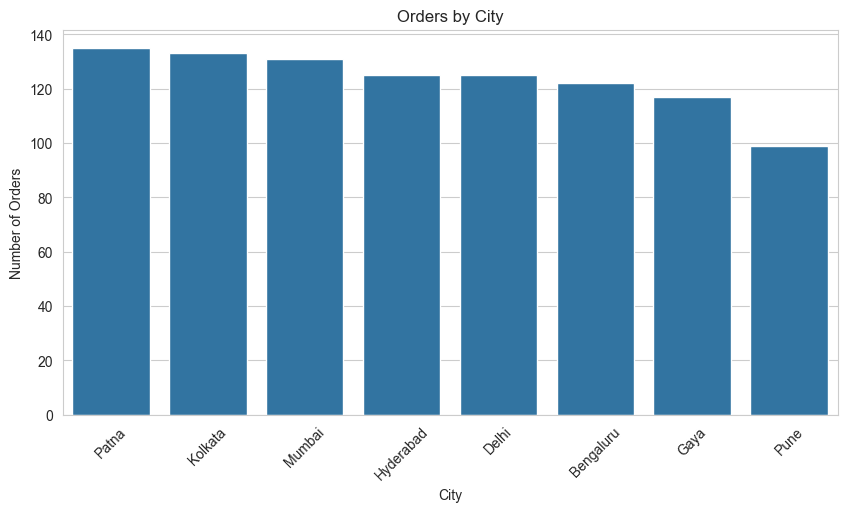

In [28]:
# category bar chart
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x="Category",
    order=df["Category"].value_counts().index
)
plt.title("Orders by Category")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=20)
plt.show()

# product bar chart
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x="Product",
    order=df["Product"].value_counts().index
)
plt.title("Orders by Product")
plt.xlabel("Product")
plt.ylabel("Number of Orders")
plt.xticks(rotation=20)
plt.show()


# gender pie chart
gender_counts = df["Gender"].value_counts()
plt.figure(figsize=(7,7))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)
plt.title("Gender Distribution")
plt.show()


# city bar chart 
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x="City",
    order=df["City"].value_counts().index
)
plt.title("Orders by City")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

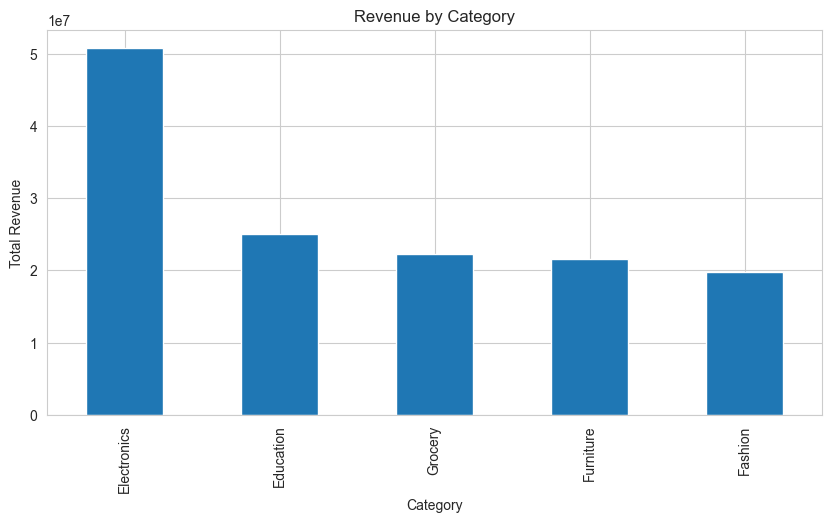

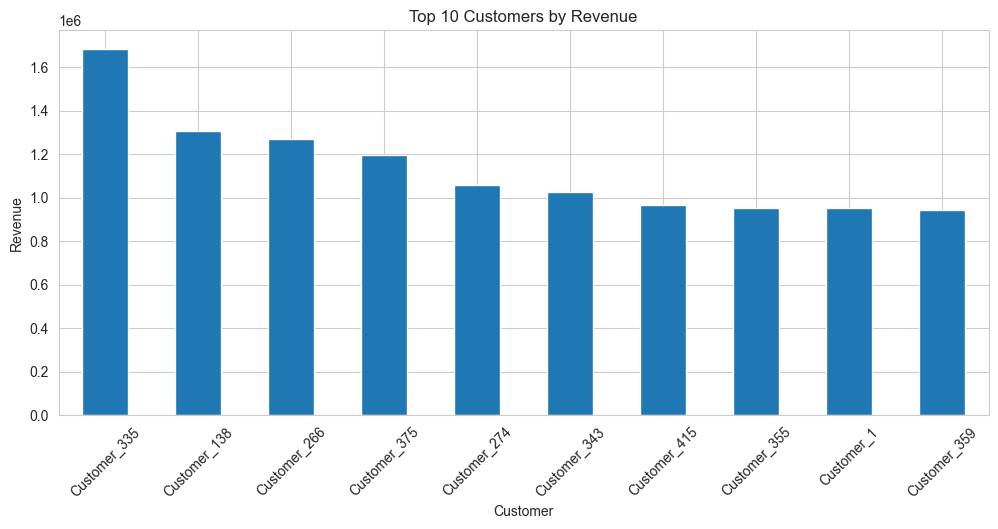



KEY INSIGHTS

Top Category : Electronics
Top Product : Mobile
Top City : Patna
Highest Revenue Category : Electronics
Total Revenue : ₹ 139399439.65
Average Order Value : ₹ 139399.44

EDA PHASE 1 COMPLETED SUCCESSFULLY


In [29]:
# sales by category 
category_sales = df.groupby("Category")["Total_Sales"].sum()
plt.figure(figsize=(10,5))
category_sales.sort_values(
    ascending=False
).plot(kind="bar")
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.show()

# top 10 customers
top_customers = (
    df.groupby("Customer_Name")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(12,5))
top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()


# summary insight
print("\n")
print("="*60)
print("KEY INSIGHTS")
print("="*60)
print(
    "\nTop Category :",
    df["Category"].value_counts().idxmax()
)
print(
    "Top Product :",
    df["Product"].value_counts().idxmax()
)
print(
    "Top City :",
    df["City"].value_counts().idxmax()
)
print(
    "Highest Revenue Category :",
    df.groupby("Category")["Total_Sales"]
      .sum()
      .idxmax()
)
print(
    "Total Revenue : ₹",
    round(df["Total_Sales"].sum(),2)
)
print(
    "Average Order Value : ₹",
    round(df["Total_Sales"].mean(),2)
)
print("\nEDA PHASE 1 COMPLETED SUCCESSFULLY")

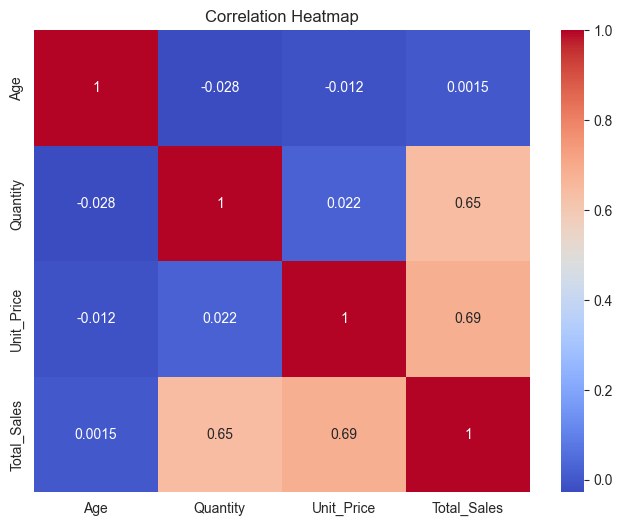

In [30]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['Age','Quantity','Unit_Price','Total_Sales']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

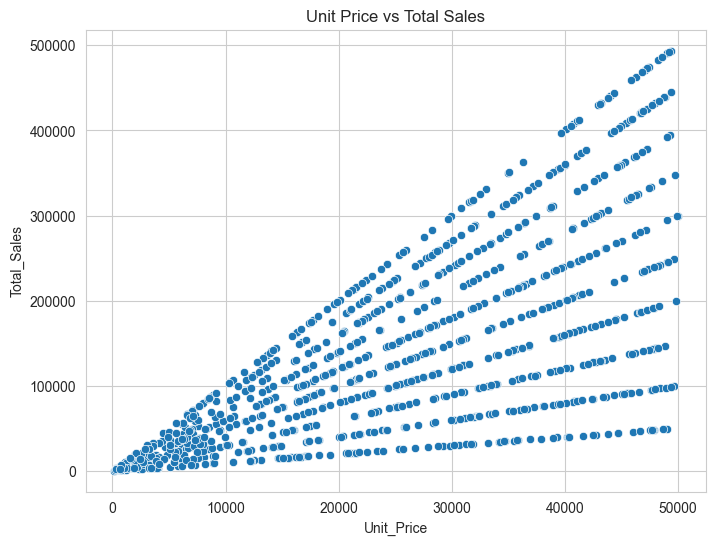

In [31]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='Unit_Price',
    y='Total_Sales'
)
plt.title("Unit Price vs Total Sales")
plt.show()

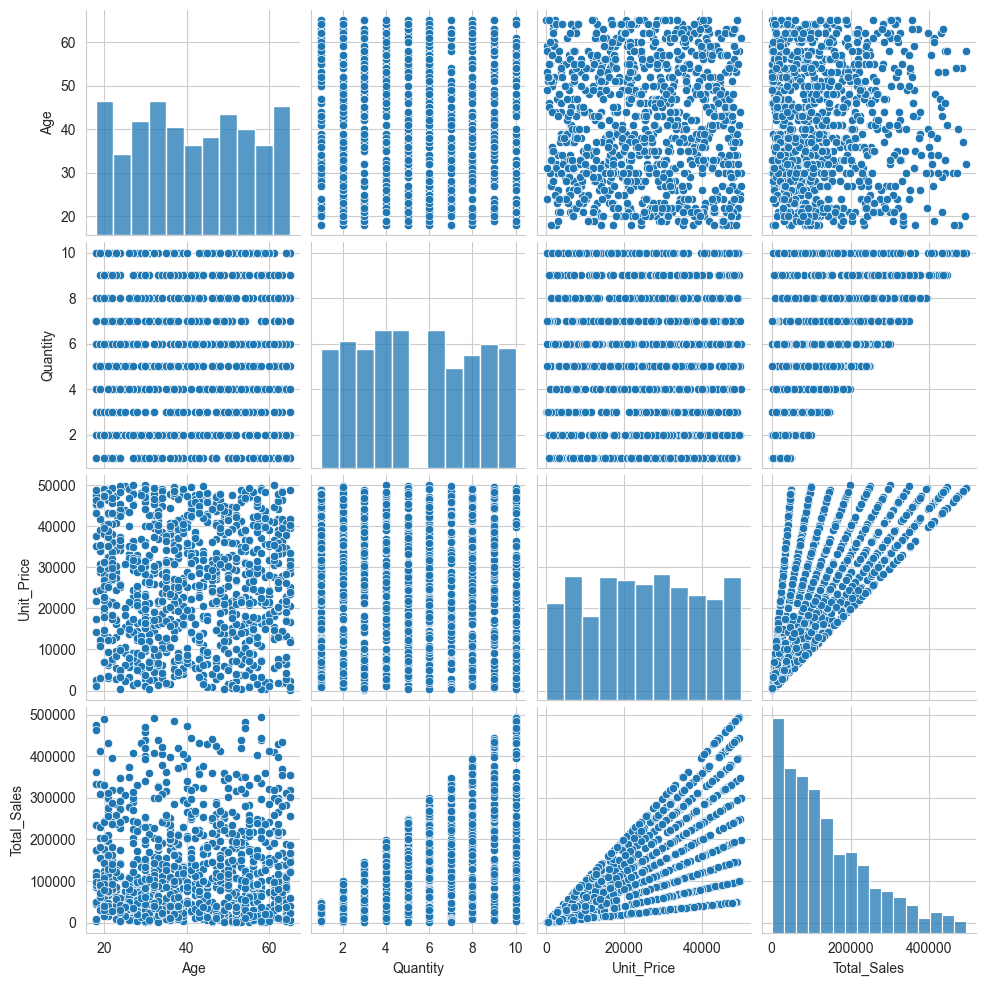

In [35]:
sns.pairplot(
    df[['Age','Quantity','Unit_Price','Total_Sales']]
)
plt.show()

In [33]:
df.to_csv("sales_data.csv", index=False)